In [1]:
import sys

# Install dependencies if the notebook is running in Colab
if 'google.colab' in sys.modules:
    !pip install -U -qq tsa-course

In [2]:
# Импорты
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from IPython.display import YouTubeVideo
import numpy as np
import pandas as pd
from scipy import signal
from scipy.integrate import cumulative_trapezoid
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import arma_generate_sample
from tsa_course.lecture2 import run_sequence_plot
from tsa_course.lecture8 import annotated_sin_plot
from sklearn.metrics import mean_squared_error

## Упражнения

### Упражнение 1

- Объедините (сложите) [синус, тренд и шум](#сигнал-с-трендом-и-шумом), которые мы определили ранее, и получите сигнал, состоящий из:
* Синусоидальной волны, представляющей сезонность.
* Параболической функции, представляющей тренд.
* и равномерно распределенного случайного шума.
- Постройте графики компонентов временной и частотной областей.
- Измените амплитуду компонентов синуса, тренда и шума так, чтобы каждый компонент, в свою очередь, доминировал над другими. Прокомментируйте, как изменяется FT общего сигнала.
- Измените синус в сигнал, который является суммой 2 синусоидальных волн разной амплитуды на 1 и 10 Гц, а также постоянного члена. Постройте графики во временной и частотной областях и прокомментируйте результаты.

In [3]:
time_ex1 = np.linspace(0, 5, 512)
y_sine_ex1 = 2*np.sin(2 * np.pi * 0.5 * time_ex1)
y_trend_ex1 = (0.5 * time_ex1)**2
y_noise_ex1 = 0.8 * np.random.randn(len(time_ex1))
signal1 = y_sine_ex1 + y_trend_ex1 + y_noise_ex1

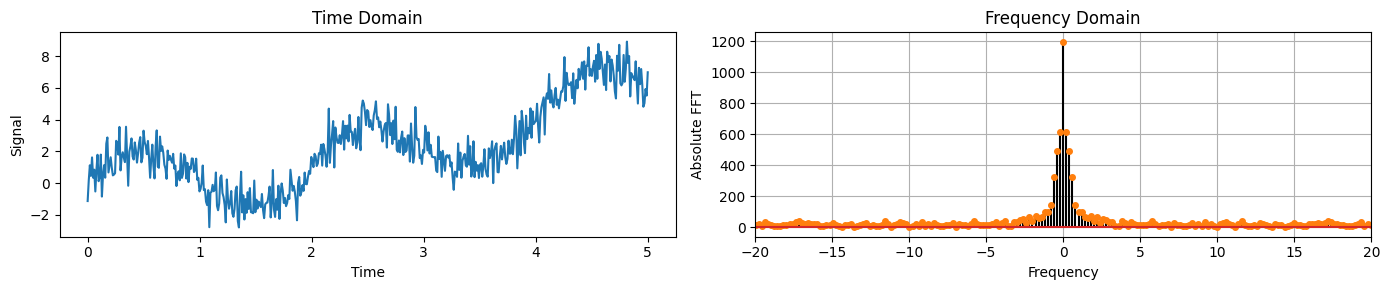

In [5]:
# Convenience function that creates both a time domain and frequency domain plot.
def plot_time_freq(t, y):
    # Converts Data into Frequncy Domain
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))

    # Time domain plot
    plt.figure(figsize = [14,3])
    plt.subplot(1,2,1)
    plt.plot(t,y)
    plt.title('Time Domain')
    plt.xlabel('Time')
    plt.ylabel('Signal')

    # Frequency domain plot
    plt.subplot(1,2,2)
    markerline, stemline, baseline = plt.stem(np.fft.fftshift(freq),np.fft.fftshift(Y),
                                              'k', markerfmt='tab:orange')
    plt.setp(stemline, linewidth = 1.5)
    plt.setp(markerline, markersize = 4)
    plt.title('Frequency Domain')
    plt.xlabel('Frequency')
    plt.xlim(-20, 20)
    plt.ylabel('Absolute FFT')
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_time_freq(time_ex1, signal1)

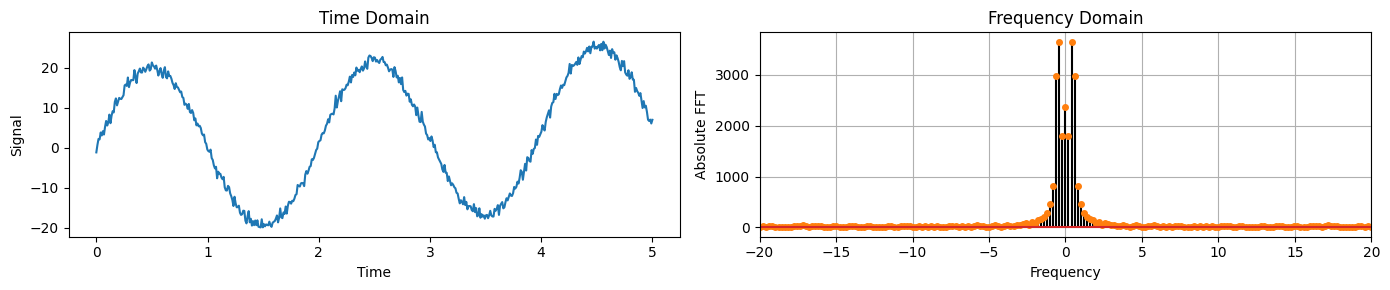

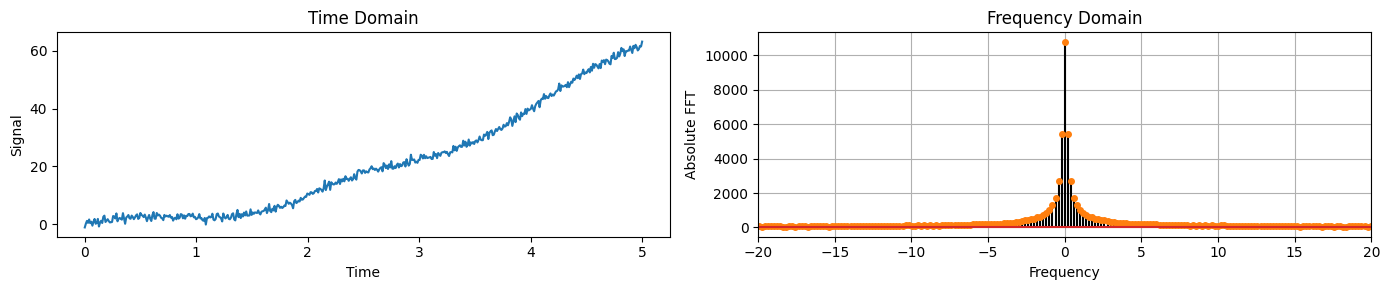

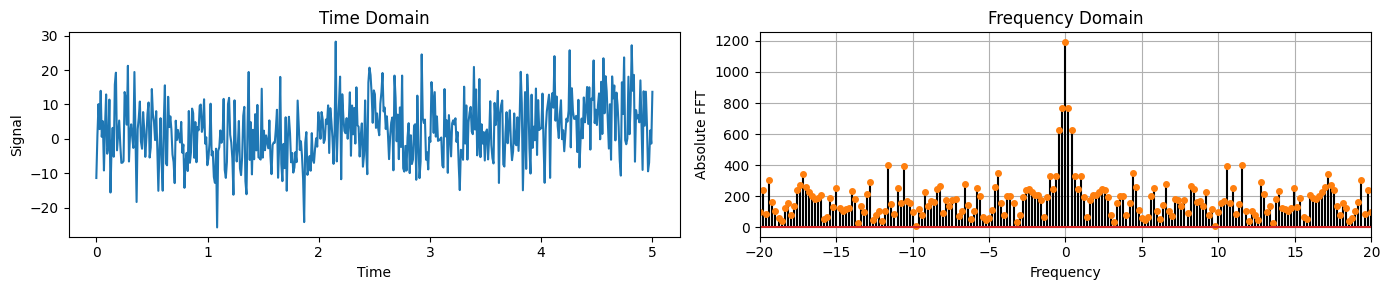

In [6]:
plot_time_freq(time_ex1, y_sine_ex1*10 + y_trend_ex1 + y_noise_ex1)
plot_time_freq(time_ex1, y_sine_ex1 + y_trend_ex1*10 + y_noise_ex1)
plot_time_freq(time_ex1, y_sine_ex1 + y_trend_ex1 + y_noise_ex1*10)

Когда доминирует синусоида, в спектре чётко виден острый пик на её частоте. Если же главным становится тренд, весь спектр концентрируется около нуля, а при доминирующем шуме - спектр выглядит почти равномерным

In [7]:
sine_1hz = np.sin(2 * np.pi * 1 * time_ex1)
sine_10hz = np.sin(2 * np.pi * 10 * time_ex1)
const_offset = 2

signal2 = sine_1hz + sine_10hz + const_offset + y_noise_ex1

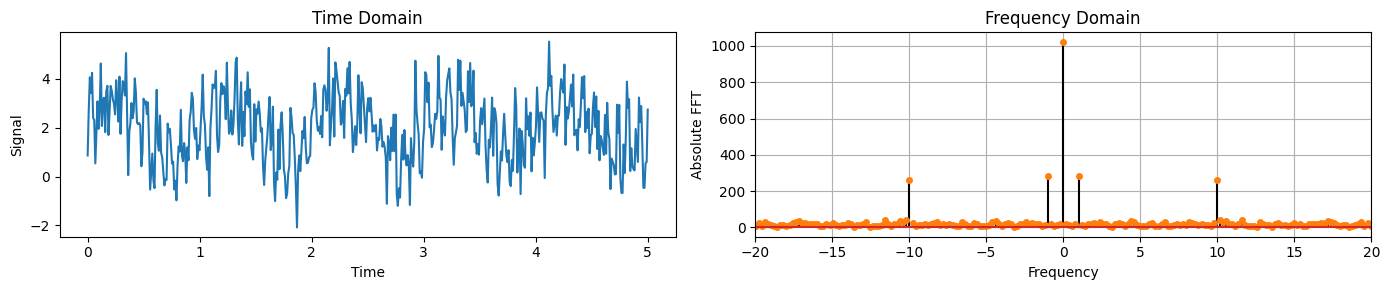

In [8]:
plot_time_freq(time_ex1, signal2)

Высота пиков соответствует амплитуде каждой компоненты

### Упражнение 2

- Рассмотрим зашумленный сигнал

In [9]:
time = np.linspace(0, 5, 512)
y_sine = 2*np.sin(2 * np.pi * 0.5 * time)
y_cos = 1.5*np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time)**2
y_noise = 0.8 * np.random.randn(len(time))
y_signal = y_sine + y_cos + y_trend

noisy_signal = y_signal + y_noise

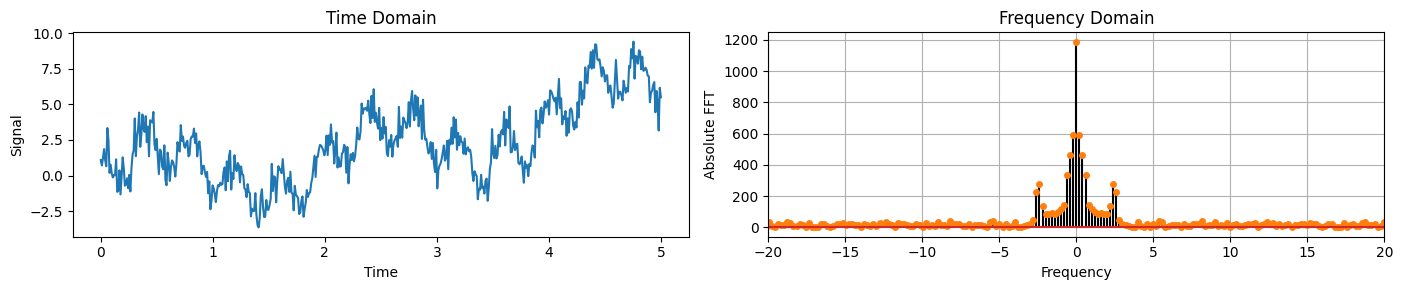

In [10]:
plot_time_freq(time, noisy_signal)

- Примените [фильтр Тьюки](#tukey-filter) к `noisy_signal`.
- Измените значения `alpha` и `div_factor` фильтра, чтобы восстановить чистый сигнал `y_signal`.

In [11]:
alpha=[x*0.01 for x in range(1, 100, 1)]
div_factor = [x for x in range(1, 100, 1)]

alpha = 0.7000000000000001, div_factor = 31
MSE = 0.05689336251972456


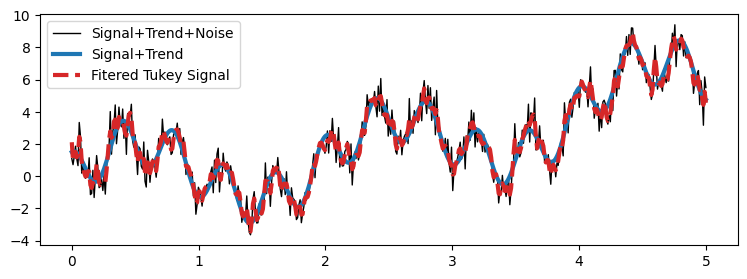

In [14]:
# Let's create a function to show the results.
def filter_plot(time, y_noisy, y_clean, y_filtered, legend_names, alpha=1):
    plt.figure(figsize=[9,3])
    plt.plot(time, y_noisy, 'k', lw=1)
    plt.plot(time, y_clean, 'tab:blue', lw=3)
    plt.plot(time, np.real(y_filtered), 'tab:red', linestyle='--', lw=3, alpha=alpha)
    plt.legend(legend_names);

max_error = 0
alpha_best = 0
div_factor_best = 0
y_tukey_best = []

for a in alpha:
    for d in div_factor:
        win_len = int(len(time) / d)
        window = signal.windows.tukey(win_len, alpha=a)

        response = np.fft.fft(window, len(time))
        response = np.abs(response / abs(response).max())

        Y = (np.fft.fft(noisy_signal))
        y_tukey = np.real(np.fft.ifft(Y*response))

        mse = mean_squared_error(y_signal, y_tukey)

        if max_error == 0:
            max_error = mse
        if mse < max_error:
            max_error = mse
            alpha_best = a
            div_factor_best = d
            y_tukey_best = y_tukey


print(f"alpha = {alpha_best}, div_factor = {div_factor_best}")
print(f"MSE = {max_error}")
filter_plot(time, noisy_signal, y_sine+y_cos+y_trend, y_tukey, ['Signal+Trend+Noise','Signal+Trend','Fitered Tukey Signal'])

### Упражнение 3

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача — восстановить `y_signal` с помощью [фильтра нижних частот Баттерворта](#butterworth-filter).
- Измените порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Какие значения кажутся наилучшими для устранения шума?

In [15]:
omega_c = [x*0.01 for x in range(1, 100, 1)]
N = [x for x in range(1, 100, 1)]

omega_c = 0.07, N = 6
MSE = 0.03000214609204202


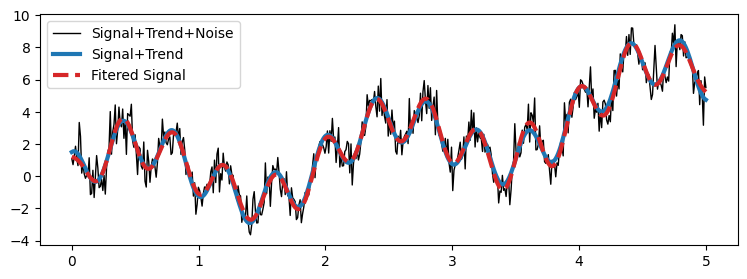

In [16]:
max_error = 0
omega_c_best = 0
N_best = 0
y_low_butter_best = []

for o in omega_c:
    for n in N:
        B, A = signal.butter(n, o, btype='lowpass', output='ba')

        y_low_butter = np.real(signal.filtfilt(B, A, noisy_signal))

        if not np.all(np.isfinite(y_low_butter)):
                continue

        mse = mean_squared_error(y_signal, y_low_butter)

        if max_error == 0:
            max_error = mse
        if mse < max_error:
            max_error = mse
            N_best = n
            omega_c_best = o
            y_low_butter_best = y_low_butter


print(f"omega_c = {omega_c_best}, N = {N_best}")
print(f"MSE = {max_error}")
filter_plot(time, noisy_signal, y_sine+y_cos+y_trend, y_low_butter_best, ['Signal+Trend+Noise','Signal+Trend','Fitered Signal'])

### Упражнение 4

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- Теперь ваша задача - восстановить `y_signal`, а затем удалить его компонент тренда (`y_trend`).
- Для этого сначала примените [фильтр высоких частот Баттерворта](#high-pass-filters-hpfs).
- Оптимизируйте вручную порядок фильтра $N$ и частоту среза $\omega_c$ фильтра Баттерворта.
- Затем примените LPF каскадно к HPF.
- Результат не должен содержать ни тренда, ни шума.

omega_c = 0.04, N = 14
MSE = 5.36968907680867


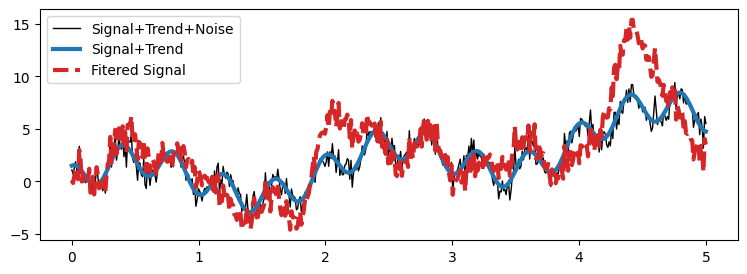

In [17]:
max_error = 0
omega_c_best_high = 0
N_best_high = 0
y_high_butter_best = []

for o in omega_c:
    for n in N:
        B, A = signal.butter(n, o, btype='highpass', output='ba')

        y_high_butter = np.real(signal.filtfilt(B, A, noisy_signal))

        if not np.all(np.isfinite(y_high_butter)):
                continue

        mse = mean_squared_error(y_signal, y_high_butter)

        if max_error == 0:
            max_error = mse
        if mse < max_error:
            max_error = mse
            N_best_high = n
            omega_c_best_high = o
            y_high_butter_best = y_high_butter


print(f"omega_c = {omega_c_best_high}, N = {N_best_high}")
print(f"MSE = {max_error}")
filter_plot(time, noisy_signal, y_sine+y_cos+y_trend, y_high_butter_best, ['Signal+Trend+Noise','Signal+Trend','Fitered Signal'])

MSE = 4.795936815290371


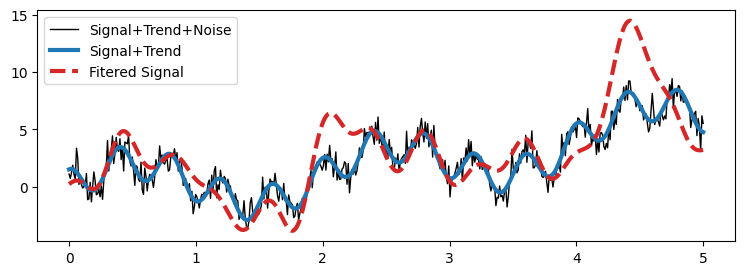

In [18]:
B, A = signal.butter(N_best, omega_c_best, btype='lowpass', output='ba')
y_low_high_butter = np.real(signal.filtfilt(B, A, y_high_butter_best))

mse_low_high = mean_squared_error(y_signal, y_low_high_butter)
print(f"MSE = {mse_low_high}")
filter_plot(time, noisy_signal, y_sine+y_cos+y_trend, y_low_high_butter, ['Signal+Trend+Noise','Signal+Trend','Fitered Signal'])

### Упражнение 5

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- И снова ваша задача - восстановить `y_signal`, а затем удалить его трендовую составляющую (`y_trend`).
- Оптимизируйте вручную порядок фильтра $N$ и частоты среза $\omega_c^\text{LOW}$ и $\omega_c^\text{HIGH}$ [полосового фильтра Баттерворта](#band-pass-filter).
- Сравните результат BPF с тем, что вы получили в [Упражнении 4](#exercise-4), когда вы применили HPF и LPF последовательно.

In [19]:
omega_c_bandpass  = [[0.01, 0.04], [0.01, 0.05], [0.01, 0.06], [0.02, 0.04], [0.02, 0.05], [0.02, 0.06], [0.03, 0.04], [0.03, 0.05], [0.03, 0.06]]
N = [x for x in range(1, 10, 1)]

omega_c = [0.01, 0.06], N = 1
MSE = 9.143482103611891


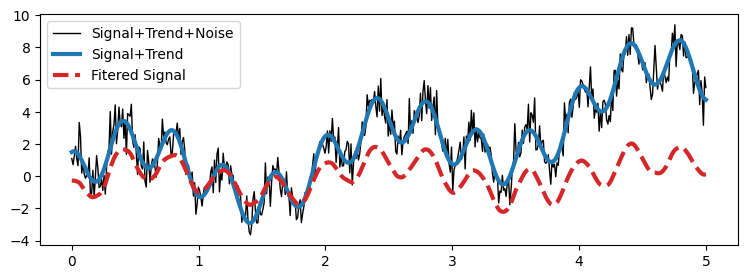

In [20]:
max_error = 0
omega_c_best_band = 0
N_best_band = 0
y_band_butter_best = []

for o in omega_c_bandpass :
    for n in N:
        B, A = signal.butter(n, o, btype='bandpass', output='ba')

        y_band_butter = np.real(signal.filtfilt(B, A, noisy_signal))

        if np.any(np.isnan(y_band_butter)):
                continue

        mse = mean_squared_error(y_signal, y_band_butter)

        if max_error == 0:
            max_error = mse
        if mse < max_error:
            max_error = mse
            N_best_band = n
            omega_c_best_band = o
            y_band_butter_best = y_band_butter


print(f"omega_c = {omega_c_best_band}, N = {N_best_band}")
print(f"MSE = {max_error}")
filter_plot(time, noisy_signal, y_sine+y_cos+y_trend, y_band_butter_best, ['Signal+Trend+Noise','Signal+Trend','Fitered Signal'])

HPF и LPF имеют меньшую ошибку, чем BPF

### Упражнение 6

- Рассмотрим `noisy_signal` из [Упражнения 2](#exercise-2).
- На этот раз вам придется удалить компонент `y_cos` из сигнала с помощью [полосового заграждающего фильтра](#band-stop-filter).

MSE = 0.6174126131897195


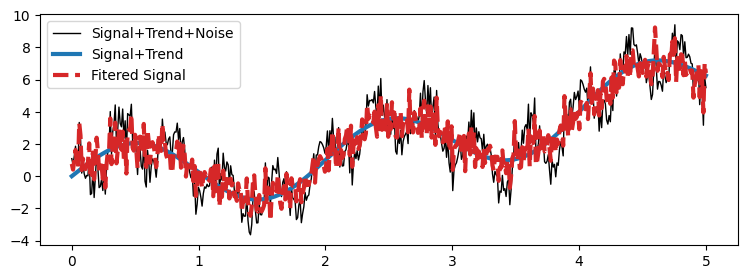

In [22]:
b_notch, a_notch = signal.butter(1, [1.5, 3.0], btype='bandstop', fs=1/(time[1]-time[0]))
y_band_notch = signal.filtfilt(b_notch, a_notch, noisy_signal)

mse_notch = mean_squared_error(y_sine + y_trend, y_band_notch)

print(f"MSE = {mse_notch}")
filter_plot(time, noisy_signal, y_sine + y_trend, y_band_notch, ['Signal+Trend+Noise','Signal+Trend','Fitered Signal'])

### Упражнение 7

- Рассмотрим данные CO2, определенные [здесь](#forecast-example-2).
- Разделите данные на обучающие и тестовые.
- Определите оптимальное количество гармоник, которое дает наилучшую MSE на тестовом наборе.

In [23]:
co2 = sm.datasets.get_rdataset("CO2", "datasets").data
co2.head()

,time,value
0,1959.000000,315.42
1,1959.083333,316.31
2,1959.166667,316.50
3,1959.250000,317.56
4,1959.333333,318.13


n_harm = 2
MSE = 2.4676


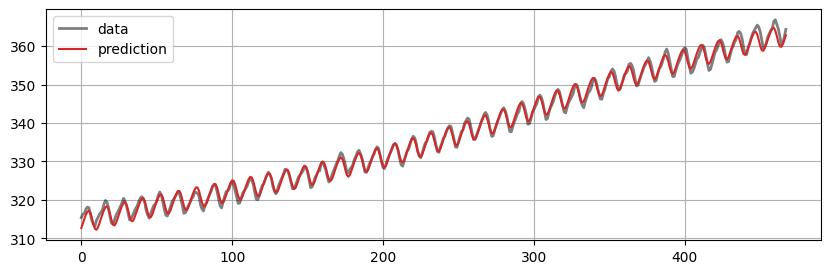

In [26]:
def fourierPrediction(y, n_predict, n_harm = 5):
    n = y.size                         # length of the time series
    t = np.arange(0, n)                # time vector
    p = np.polyfit(t, y, 1)            # find linear trend in x
    y_notrend = y - p[0] * t - p[1]    # detrended x
    y_freqdom = np.fft.fft(y_notrend)  # detrended x in frequency domain
    f = np.fft.fftfreq(n)              # frequencies

    # Sort indexes by largest frequency components
    indexes = np.argsort(np.absolute(y_freqdom))[::-1]

    t = np.arange(0, n + n_predict)
    restored_sig = np.zeros(t.size)
    for i in indexes[:1 + n_harm * 2]:
        amp = np.absolute(y_freqdom[i]) / n   # amplitude
        phase = np.angle(y_freqdom[i])        # phase
        restored_sig += amp * np.cos(2 * np.pi * f[i] * t + phase)
    return restored_sig + p[0] * t + p[1] # add back the trend

def fourierPredictionPlot(y, prediction):
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(0, y.size), y, 'k', label = 'data', linewidth = 2, alpha=0.5)
    plt.plot(np.arange(0, prediction.size), prediction, 'tab:red', label = 'prediction')
    plt.grid()
    plt.legend()
    plt.show()

n_harm_values = [x for x in range(1, 30)]
max_error = 0
best_n_harm = 1
best_fourier = []

train_size = len(co2['value']) - 50
train_data = co2['value'][:train_size]

for n_harm in n_harm_values:
    fourier = fourierPrediction(train_data, n_predict=50, n_harm=n_harm)

    actual = co2['value'][train_size:train_size+50]
    predicted = fourier[train_size:train_size+50]

    mse = np.mean((actual - predicted) ** 2)

    if max_error == 0:
            max_error = mse
    if mse < max_error:
        max_error = mse
        best_n_harm = n_harm
        best_fourier = fourier

print(f"n_harm = {best_n_harm}")
print(f"MSE = {max_error:.4f}")
fourierPredictionPlot(co2['value'], best_fourier)
